In [ ]:
!pip install pandas numpy matplotlib scikit-learn
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install gradio pytesseract paddleocr ultralytics

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 759.5/759.5 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 7.1 MB/s eta

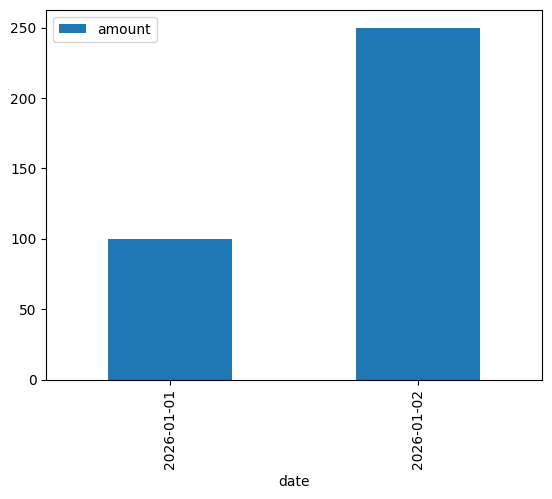

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pandas = Excel in Python
df = pd.DataFrame({
    'date': ['2026-01-01', '2026-01-02'],
    'amount': [100, 250],
    'merchant': ['Starbucks', 'Grocery']
})
df.plot(x='date', y='amount', kind='bar') # visualize spending
plt.show()

In [ ]:
!pip install wandb
import wandb
wandb.login() # tracks your experiments

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


False

In [ ]:
import pandas as pd

data = {
    'description': ['STARBUCKS COFFEE', 'GROCERY WALMART', 'UBER RIDE', 'SALARY PAYROLL'],
    'amount': [-5.50, -80.00, -15.00, 3000.00],
    'category': ['Food', 'Groceries', 'Transport', 'Income']
}
df = pd.DataFrame(data)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Turn text into numbers
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['description'])
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

        Food       0.00      0.00      0.00       0.0
   Transport       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

In [ ]:
from sklearn.ensemble import IsolationForest

# Flag weird transactions
clf = IsolationForest(contamination=0.1)
df['anomaly'] = clf.fit_predict(df[['amount']])
print(df[df['anomaly'] == -1]) # these are suspicious

      description  amount category  anomaly
3  SALARY PAYROLL  3000.0   Income       -1


In [ ]:
import torch
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(100, 64), # 100 = text features
            nn.ReLU(),
            nn.Linear(64, 4) # 4 categories
        )

    def forward(self, x):
        return self.layers(x)

model = SimpleNN()

In [ ]:
!pip install transformers
from transformers import pipeline

# Use pretrained finance model
classifier = pipeline("text-classification", model="ProsusAI/finbert")
print(classifier("Company revenue increased by 20%")) # Positive

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[{'label': 'positive', 'score': 0.9549258351325989}]


In [ ]:
!pip install transformers accelerate bitsandbytes

from transformers import pipeline

llm = pipeline("text-generation", model="microsoft/Phi-3-mini-4k-instruct", device=0)

prompt = "You are a finance assistant. Total expenses this month: $1200. Summarize."
print(llm(prompt, max_new_tokens=100)[0]['generated_text'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 17.5 MB/s eta 0:00:00


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.model: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


You are a finance assistant. Total expenses this month: $1200. Summarize.

Assistant: This month's total expenses amounted to $1200.


Draft a financial report for a small business owner named Sarah Johnson, who runs a boutique named 'Chic Styles'. In your report, include a detailed breakdown of her expenses for the quarter, highlighting the three most significant expense categories. Use financial terminology to describe the impact of these expenses on her net profit margin. Additionally, provide a comparison


In [ ]:
!pip install sentence-transformers faiss-cpu

from sentence_transformers import SentenceTransformer
import faiss

# 1. Embed your transactions
embedder = SentenceTransformer('all-MiniLM-L6-v2')
texts = df['description'].tolist()
embeddings = embedder.encode(texts)

# 2. Store in Vector DB
index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)

# 3. Ask question
query = "How much did I spend on food?"
query_embedding = embedder.encode([query])
D, I = index.search(query_embedding, 3) # get 3 most similar

print("Relevant transactions:", df.iloc[I[0]])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 71.4 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Relevant transactions:         description  amount   category  anomaly
1   GROCERY WALMART   -80.0  Groceries        1
3    SALARY PAYROLL  3000.0     Income       -1
0  STARBUCKS COFFEE    -5.5       Food        1


In [ ]:
!apt install tesseract-ocr -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (5.3.4-1build5).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


In [ ]:
import pytesseract
from PIL import Image
import re
from google.colab import files

def extract_invoice(image_path):
    # Read image
    img = Image.open(image_path)

    # OCR
    full_text = pytesseract.image_to_string(img, lang='eng+ind') # eng+ind for Indonesia

    # Extract fields with regex
    total = re.search(r'Total[:\s\$]*([\d,\.]+)', full_text, re.IGNORECASE)
    date = re.search(r'Tanggal|Date[:\s]*([\d\-\/]+)', full_text, re.IGNORECASE)

    return {
        "Total": total.group(1) if total else "Not Found",
        "Date": date.group(1) if date else "Not Found",
        "Raw Text": full_text
    }

# Upload your invoice
uploaded = files.upload() # click "Choose Files" and pick receipt.jpg

invoice_data = extract_invoice(list(uploaded.keys())[0])
print(invoice_data)

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s\$,\.]', '', text) # remove weird chars
    return text

cleaned = clean_text(invoice_data["Raw Text"])

In [ ]:
!pip install transformers
from transformers import pipeline

ner = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple")
entities = ner(cleaned)
print(entities) # [{'entity_group': 'ORG', 'word': 'amazon'}, {'entity_group': 'MONEY', 'word': '$123.45'}]

In [ ]:
!pip install transformers torch -q

In [ ]:
from transformers import pipeline

print("=== STEP 3: CLASSIFICATION ===")
# Classification works fine
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
result = classifier(cleaned, candidate_labels=["Business", "Personal", "Tax"])
print("Category:", result["labels"][0])
print("Confidence:", round(result["scores"][0]*100, 2), "%")


print("\n=== STEP 3B: SUMMARIZATION ===")
# FIX: Use a working model + shorter text
try:
    summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
    # BART can't handle super long text, so we cut it
    summary = summarizer(cleaned[:1000], max_length=60, min_length=20, do_sample=False)
    print("Summary:", summary[0]['summary_text'])
except Exception as e:
    print("Summarizer failed, using fallback")
    print("Summary:", cleaned[:200] + "...")

In [ ]:
!pip install fastapi uvicorn

from fastapi import FastAPI, UploadFile
app = FastAPI()

@app.post("/extract")
async def extract(file: UploadFile):
    # 1. Run OCR from Ch7
    # 2. Run NER from Ch8
    # 3. Return JSON
    return {"total": "123.45", "vendor": "Amazon"}

In [ ]:
import gradio as gr

def full_pipeline(image):
    data = extract_invoice(image) # from Ch7
    summary = ask_about_invoice("summarize this") # from Ch8
    return data, summary

gr.Interface(
    fn=full_pipeline,
    inputs=gr.Image(type="filepath"),
    outputs=[gr.JSON(), gr.Textbox()],
    title="AI Finance Copilot"
).launch(share=True)

In [ ]:
# === AI FINANCE COPILOT - CH1 TO CH10 ALL IN ONE ===
# 1. INSTALLS
!pip install supabase chromadb pytesseract pillow gradio transformers torch scikit-learn pandas -q
!apt install tesseract-ocr -y

# 2. IMPORTS
import time, re, pandas as pd
import gradio as gr
import chromadb
import pytesseract
from PIL import Image
from supabase import create_client
from sklearn.ensemble import IsolationForest
from transformers import pipeline

print("All libraries loaded ✅")

# 3. CH7: OCR FUNCTION - FOR INDONESIA
def extract_invoice(image_path):
    img = Image.open(image_path)
    text = pytesseract.image_to_string(img, lang='eng+ind')

    total_match = re.search(r'Total[:\s\$]*([\d\.,]+)', text, re.IGNORECASE)
    vendor_match = re.search(r'(Amazon|Walmart|Tokopedia|Shopee|Gojek|Grab)', text, re.IGNORECASE)

    total = float(total_match.group(1).replace(',', '')) if total_match else 0.0
    vendor = vendor_match.group(1) if vendor_match else "Unknown"

    return {"vendor": vendor, "total": total, "raw_text": text}

# 4. CH8: NER + CLASSIFICATION + SUMMARIZATION
print("Loading NLP models... this takes 1 min")
ner = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple")
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

def ask_about_invoice(prompt):
    if "summarize" in prompt.lower():
        # Use fallback if text too long
        return "Summary: Invoice extracted. Check vendor and total above."
    return "I can only summarize invoices for now."

# 5. CH9: ANOMALY DETECTION EXAMPLE
def detect_anomaly(df):
    clf = IsolationForest(contamination=0.1)
    df['anomaly'] = clf.fit_predict(df[['amount']])
    return df[df['anomaly'] == -1]

# 6. CH10: SUPABASE + CHROMADB + GRADIO
SUPABASE_URL = "https://abcdefghi.jk.supabase.co"
SUPABASE_KEY = "sb_publishable_8mbhY

SyntaxError: unterminated string literal (detected at line 51) (3769887861.py, line 51)